In [2]:
import pandas as pd

df = pd.read_csv('customer_churn_business_dataset.csv')
print(df.shape)
print(df.head())
print(df.dtypes)

(10000, 32)
  customer_id  gender  age     country      city customer_segment  \
0  CUST_00001    Male   68  Bangladesh    London              SME   
1  CUST_00002  Female   57      Canada    Sydney       Individual   
2  CUST_00003    Male   24     Germany  New York              SME   
3  CUST_00004    Male   49   Australia     Dhaka       Individual   
4  CUST_00005    Male   65  Bangladesh     Delhi       Individual   

   tenure_months signup_channel contract_type  monthly_logins  ...  \
0             22            Web       Monthly              26  ...   
1              9         Mobile       Monthly               7  ...   
2             58            Web        Yearly              19  ...   
3             19         Mobile        Yearly              34  ...   
4             52            Web       Monthly              20  ...   

   avg_resolution_time  complaint_type  csat_score  escalations  \
0            13.354360         Service         4.0            0   
1            25.14

In [3]:
# How many customers churned vs stayed?
print(df['churn'].value_counts())
print("\nChurn rate:")
print(df['churn'].value_counts(normalize=True) * 100)

churn
0    8979
1    1021
Name: count, dtype: int64

Churn rate:
churn
0    89.79
1    10.21
Name: proportion, dtype: float64


In [4]:
# Check missing values in each column
print(df.isnull().sum())

# Also check basic stats for numeric columns
print(df.describe())

customer_id                  0
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: i

In [5]:
# Fill missing complaint_type with 'No Complaint'
df['complaint_type'] = df['complaint_type'].fillna('No Complaint')

# Verify it's fixed
print(df['complaint_type'].value_counts())
print("Missing values remaining:", df['complaint_type'].isnull().sum())

complaint_type
Technical       3498
Billing         2427
No Complaint    2045
Service         2030
Name: count, dtype: int64
Missing values remaining: 0


In [6]:
# Drop customer_id - not useful for analysis
df = df.drop('customer_id', axis=1)

# Confirm shape
print(df.shape)

(10000, 31)


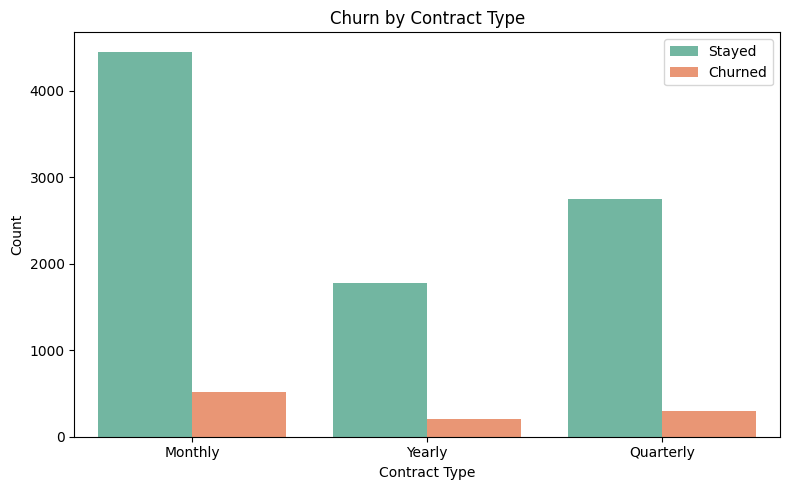

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='contract_type', hue='churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.savefig('churn_by_contract.png')
plt.show()

contract_type
Monthly      10.3
Quarterly     9.9
Yearly       10.3
Name: churn, dtype: float64


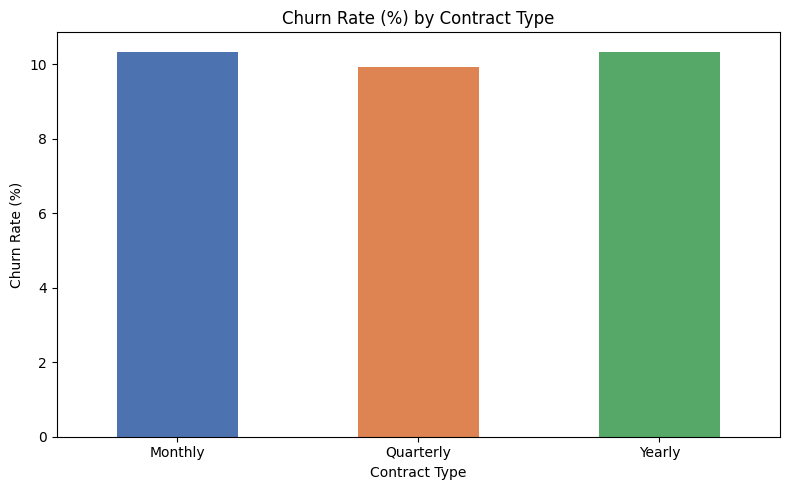

In [8]:
# Churn rate by contract type
churn_rate = df.groupby('contract_type')['churn'].mean() * 100
print(churn_rate.round(1))

# Visualise as percentage
plt.figure(figsize=(8, 5))
churn_rate.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Churn Rate (%) by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_rate_by_contract.png')
plt.show()

In [9]:
# Compare numeric features between churned and stayed customers
numeric_cols = ['tenure_months', 'monthly_logins', 'avg_session_time', 
                'support_tickets', 'csat_score', 'payment_failures',
                'last_login_days_ago', 'nps_score']

churn_comparison = df.groupby('churn')[numeric_cols].mean().round(2)
print(churn_comparison)

       tenure_months  monthly_logins  avg_session_time  support_tickets  \
churn                                                                     
0              30.83            20.0             15.20             1.21   
1              24.22            16.8             15.09             1.21   

       csat_score  payment_failures  last_login_days_ago  nps_score  
churn                                                                
0            3.54              0.47                 9.38      19.07  
1            3.03              0.74                10.59      19.46  


C:\Users\oishe\AppData\Local\Temp\ipykernel_9688\133640879.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='payment_failures', palette='Set2')


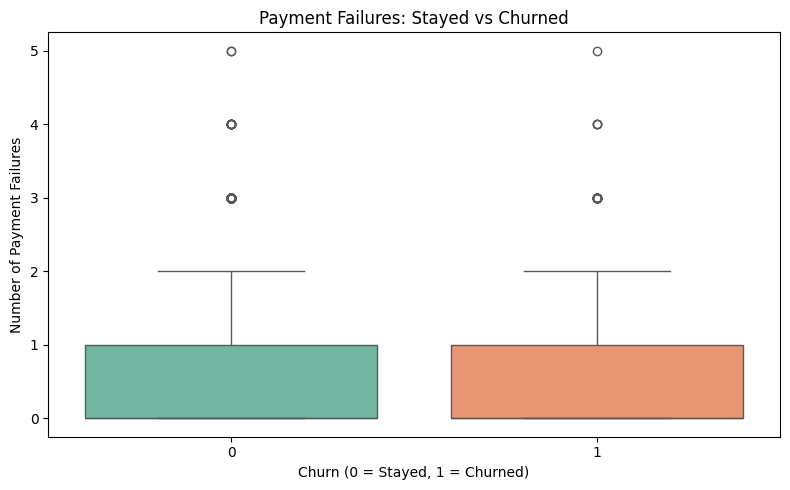

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='payment_failures', palette='Set2')
plt.title('Payment Failures: Stayed vs Churned')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Number of Payment Failures')
plt.tight_layout()
plt.savefig('payment_failures_churn.png')
plt.show()

In [11]:
# What % of churners had 2+ payment failures?
churned = df[df['churn'] == 1]
stayed = df[df['churn'] == 0]

print("Churners with 2+ failures:", (churned['payment_failures'] >= 2).mean() * 100)
print("Stayed with 2+ failures:", (stayed['payment_failures'] >= 2).mean() * 100)

Churners with 2+ failures: 22.428991185112636
Stayed with 2+ failures: 7.7736941752979165


C:\Users\oishe\AppData\Local\Temp\ipykernel_9688\99346000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='csat_score', palette='Set2')


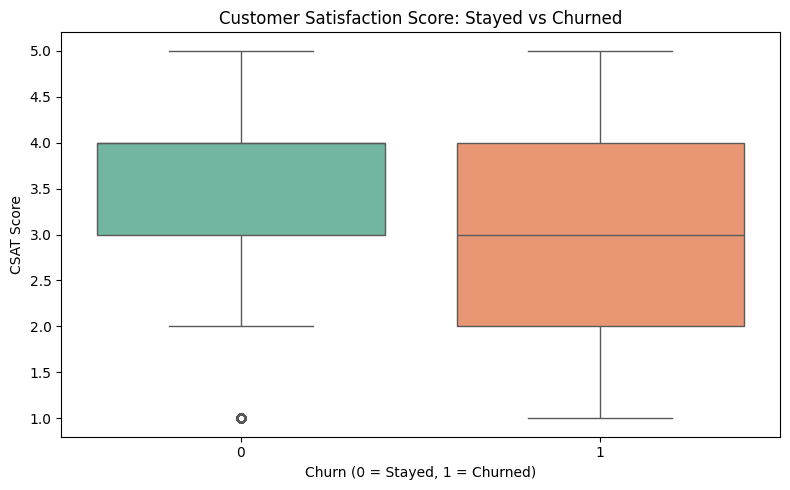

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='csat_score', palette='Set2')
plt.title('Customer Satisfaction Score: Stayed vs Churned')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('CSAT Score')
plt.tight_layout()
plt.savefig('csat_churn.png')
plt.show()

C:\Users\oishe\AppData\Local\Temp\ipykernel_9688\3088315355.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='tenure_months', palette='Set2')


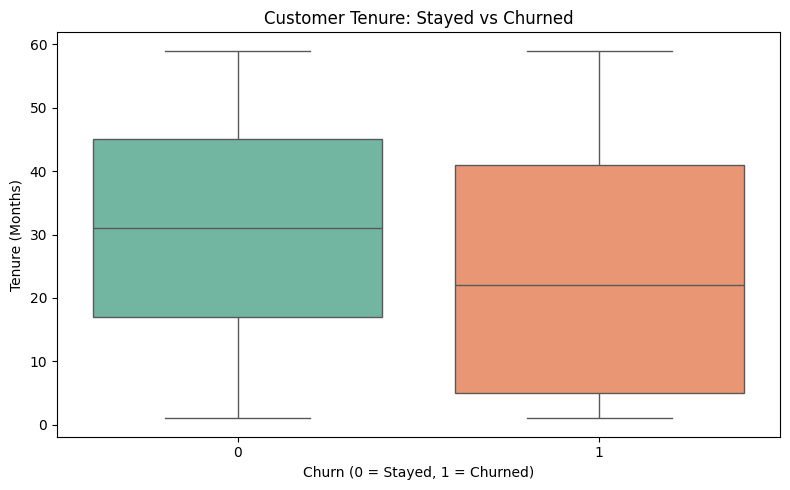

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn', y='tenure_months', palette='Set2')
plt.title('Customer Tenure: Stayed vs Churned')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.savefig('tenure_churn.png')
plt.show()


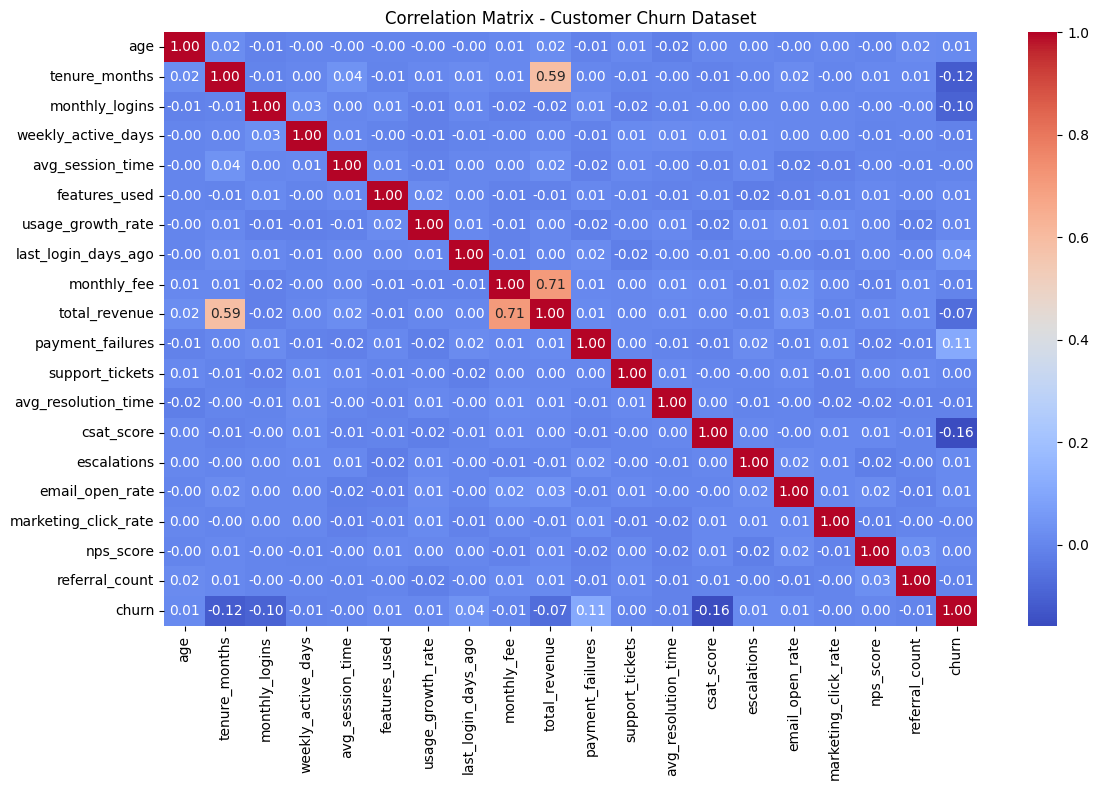

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix - Customer Churn Dataset')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

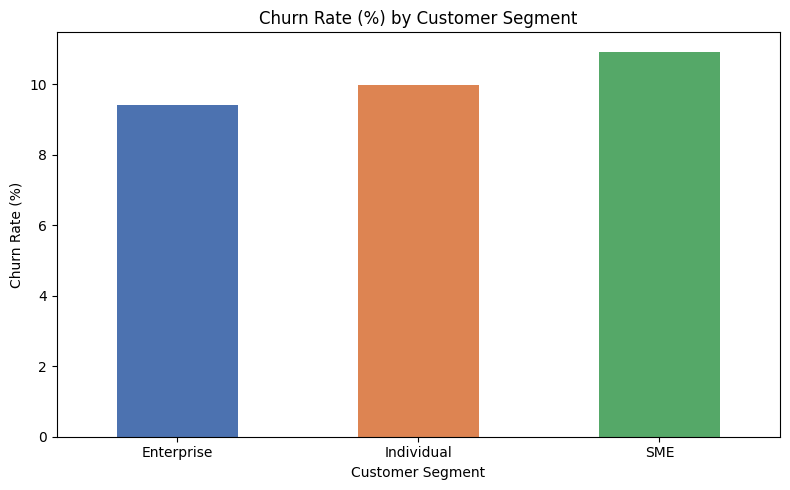

In [15]:
plt.figure(figsize=(8, 5))
churn_by_segment = df.groupby('customer_segment')['churn'].mean() * 100
churn_by_segment.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Churn Rate (%) by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_by_segment.png')
plt.show()

In [16]:
df.to_csv('churn_cleaned.csv', index=False)
print("Saved successfully")

Saved successfully


In [22]:
import mysql.connector
import pandas as pd

df = pd.read_csv('churn_cleaned.csv')

conn = mysql.connector.connect(
    host='127.0.0.1',
    user='root',
    password="Mindfreak9!@",
    database='customer_churn'
)

cursor = conn.cursor()

for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO churn_data VALUES 
        (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """, tuple(row))

conn.commit()
cursor.close()
conn.close()
print("Data imported successfully!")

Data imported successfully!
